# Problem Statement

**According to weather and soil condition we have to predict crop for yeild.**

In [72]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
# ! pip install seaborn

In [74]:
df=pd.read_csv('Crop_Yeild_Prediction.csv')
df.head()

,Unnamed: 0,State_Name,Crop_Type,Crop,N,P,K,pH,rainfall,temperature,Area_in_hectares,Production_in_tons,Yield_ton_per_hec
0,0,andhra pradesh,kharif,cotton,120,40,20,5.46,654.34,29.266667,7300.0,9400.0,1.287671
1,1,andhra pradesh,kharif,horsegram,20,60,20,6.18,654.34,29.266667,3300.0,1000.0,0.303030
2,2,andhra pradesh,kharif,jowar,80,40,40,5.42,654.34,29.266667,10100.0,10200.0,1.009901
3,3,andhra pradesh,kharif,maize,80,40,20,5.62,654.34,29.266667,2800.0,4900.0,1.750000
4,4,andhra pradesh,kharif,moong,20,40,20,5.68,654.34,29.266667,1300.0,500.0,0.384615


# Inferences
1. The dataset contains complete agricultural information for different crops and states, suggesting comprehensive coverage and reliability.

2. With no missing values in any feature, the dataset ensures data completeness, facilitating straightforward analysis of agricultural trends.

In [75]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [76]:
df.head()

,State_Name,Crop_Type,Crop,N,P,K,pH,rainfall,temperature,Area_in_hectares,Production_in_tons,Yield_ton_per_hec
0,andhra pradesh,kharif,cotton,120,40,20,5.46,654.34,29.266667,7300.0,9400.0,1.287671
1,andhra pradesh,kharif,horsegram,20,60,20,6.18,654.34,29.266667,3300.0,1000.0,0.303030
2,andhra pradesh,kharif,jowar,80,40,40,5.42,654.34,29.266667,10100.0,10200.0,1.009901
3,andhra pradesh,kharif,maize,80,40,20,5.62,654.34,29.266667,2800.0,4900.0,1.750000
4,andhra pradesh,kharif,moong,20,40,20,5.68,654.34,29.266667,1300.0,500.0,0.384615


### Features Nomenclature

1. **State_Name:**
   - Description: Name of the state where the crop was grown.
   - Type: Categorical

2. **Crop_Type:**
   - Description: Type of crop (e.g., kharif, rabi).
   - Type: Categorical

3. **Crop:**
   - Description: Name of the specific crop.
   - Type: Categorical

4. **N:**
   - Description: Amount of Nitrogen used in fertilization (in kg per hectare).
   - Type: Numeric

5. **P:**
   - Description: Amount of Phosphorus used in fertilization (in kg per hectare).
   - Type: Numeric

6. **K:**
   - Description: Amount of Potassium used in fertilization (in kg per hectare).
   - Type: Numeric

7. **pH:**
   - Description: Soil pH level.
   - Type: Numeric

8. **rainfall:**
   - Description: Average annual rainfall in mm.
   - Type: Numeric

9. **temperature:**
   - Description: Average annual temperature in Celsius.
   - Type: Numeric

10. **Area_in_hectares:**
    - Description: Area of land used for crop cultivation in hectares.
    - Type: Numeric

11. **Production_in_tons:**
    - Description: Total production of the crop in tons.
    - Type: Numeric

12. **Yield_ton_per_hec:**
    - Description: Yield of the crop per hectare (tons per hectare).
    - Type: Numeric


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99849 entries, 0 to 99848
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State_Name          99849 non-null  object 
 1   Crop_Type           99849 non-null  object 
 2   Crop                99849 non-null  object 
 3   N                   99849 non-null  int64  
 4   P                   99849 non-null  int64  
 5   K                   99849 non-null  int64  
 6   pH                  99849 non-null  float64
 7   rainfall            99849 non-null  float64
 8   temperature         99849 non-null  float64
 9   Area_in_hectares    99849 non-null  float64
 10  Production_in_tons  99849 non-null  float64
 11  Yield_ton_per_hec   99849 non-null  float64
dtypes: float64(6), int64(3), object(3)
memory usage: 9.1+ MB


# Inferences
1. The dataset contains complete agricultural information for different crops and states, suggesting comprehensive coverage and reliability.

2. With no missing values in any feature, the dataset ensures data completeness, facilitating straightforward analysis of agricultural trends.

In [78]:
df['Crop_Type'].unique()

array(['kharif', 'rabi', 'summer', 'whole year'], dtype=object)

In [79]:
df.describe()

,N,P,K,pH,rainfall,temperature,Area_in_hectares,Production_in_tons,Yield_ton_per_hec
count,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,9.984900e+04,99849.000000
mean,69.816823,41.593656,42.037827,5.643624,701.151085,26.684154,16476.585668,3.776291e+04,3.931149
std,39.571469,15.056508,28.430263,0.505283,604.701552,4.851214,43604.268231,1.222447e+05,33.872242
min,10.000000,10.000000,10.000000,3.820000,3.274569,1.180000,0.580000,0.000000e+00,0.000000
25%,50.000000,40.000000,20.000000,5.360000,157.310000,23.106000,130.000000,1.620000e+02,0.586207
50%,75.000000,40.000000,30.000000,5.540000,579.750000,27.333333,1010.000000,1.506000e+03,1.329268
75%,80.000000,60.000000,50.000000,5.960000,1110.780000,29.266667,8099.000000,1.439500e+04,2.997288
max,180.000000,125.000000,200.000000,7.000000,3322.060000,35.346667,726300.000000,3.530571e+06,9801.000000


### Inferences
1. **N (Nitrogen):** The mean nitrogen level is 69.82 kg/ha, with a wide range from 10 to 180 kg/ha, indicating varying fertilization practices among crops.

2. **P (Phosphorus):** The mean phosphorus level is 41.59 kg/ha, suggesting moderate usage across crops, with a minimum of 10 kg/ha and a maximum of 125 kg/ha.

3. **K (Potassium):** The mean potassium level is 42.04 kg/ha, with significant variability from 10 to 200 kg/ha, reflecting diverse soil nutrient management strategies.

4. **pH:** The average soil pH is 5.64, indicating slightly acidic conditions, with values ranging from 3.82 to 7.00, highlighting the importance of pH regulation for optimal crop growth.

5. **Rainfall:** The mean annual rainfall is 701.15 mm, with substantial variability from 3.27 mm to 3322.06 mm, underscoring the influence of climatic factors on crop production.

6. **Temperature:** The average annual temperature is 26.68°C, with temperatures ranging from 1.18°C to 35.35°C, suggesting diverse climatic conditions affecting crop growth.

7. **Area_in_hectares:** The mean area used for cultivation is 16476.59 hectares, with considerable variability, ranging from small-scale to large-scale farming operations.

8. **Production_in_tons:** The mean crop production is 37762.91 tons, with a wide range from minimal to substantial yields, reflecting the productivity levels across different crops and regions.

9. **Yield_ton_per_hec:** The mean yield per hectare is 3.93 tons, with values ranging from 0 to 9801 tons per hectare, indicating varying levels of crop productivity and efficiency in agricultural practices.

In [80]:
df.describe(include='O')

,State_Name,Crop_Type,Crop
count,99849,99849,99849
unique,33,4,53
top,uttar pradesh,kharif,rice
freq,12598,38758,11430


### Inferences
1. **State_Name:** Uttar Pradesh dominates in crop cultivation, with 33 unique states represented, indicating a diverse geographical spread of agricultural activity across regions.

2. **Crop_Type:** Kharif crops are predominant, with 4 unique crop types, suggesting a seasonal focus on rain-fed crops, highlighting agricultural practices aligned with monsoon patterns.

3. **Crop:** Rice emerges as the most cultivated crop, with 53 unique crops grown, underscoring the importance of staple foods in agricultural production and dietary sustenance.

<h2 style='font-family:rockwell; color:#06917e'> Exploratory Data Analysis</h2>

<h2 style='font-family:rockwell; color:#06917e'> Univariate Analysis</h2>

**For Numerical Column** 
1. Kernel Density Plot (KDE) - Data Distribution (Data is Skewed or Data is Normaly Distributed) 

2. Histogram- To Check The Frequency of Data 

3. Box Plot- To Check Outliers are Present or not

**For Categorical Data**
1. Count Plot - to check the each category count 

2. Pie Plot - in percentage you will get the output 

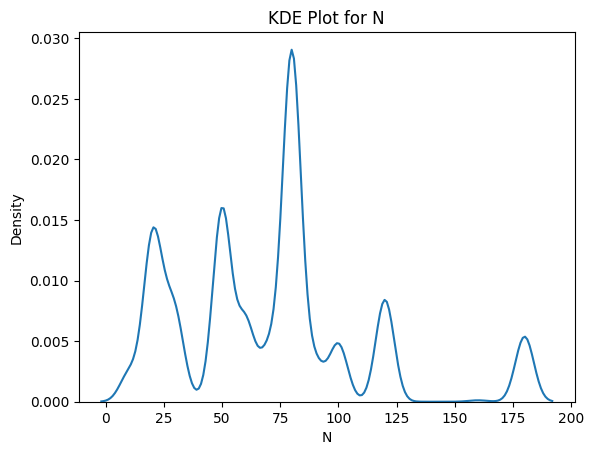

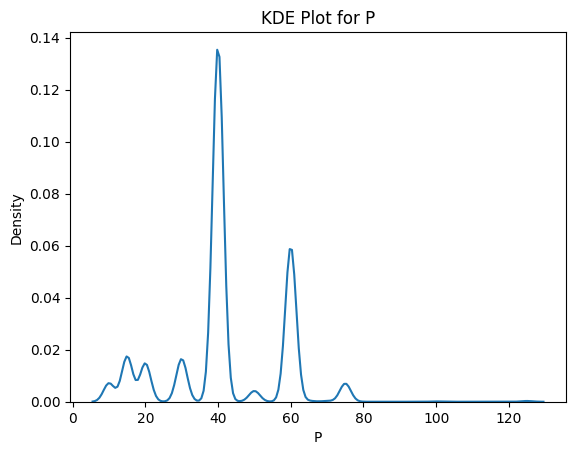

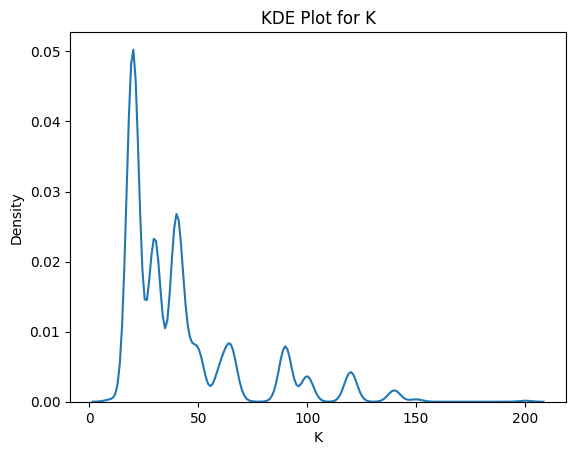

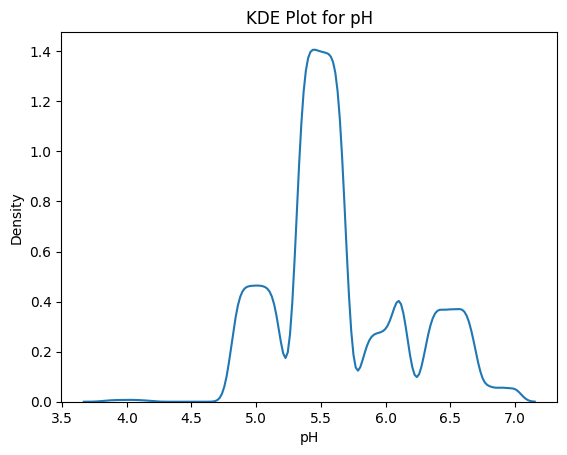

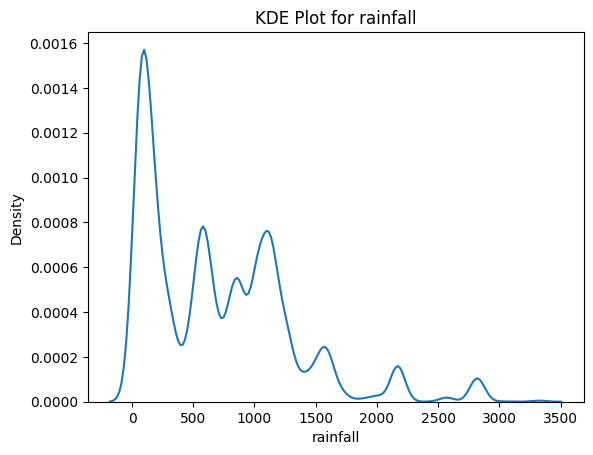

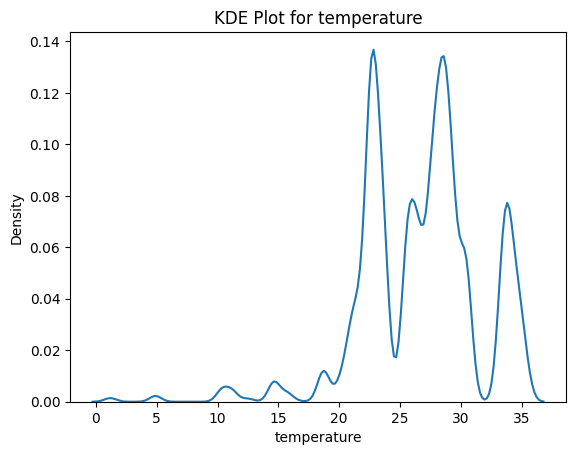

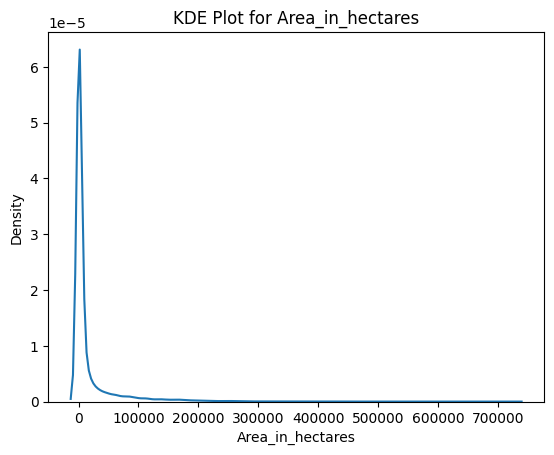

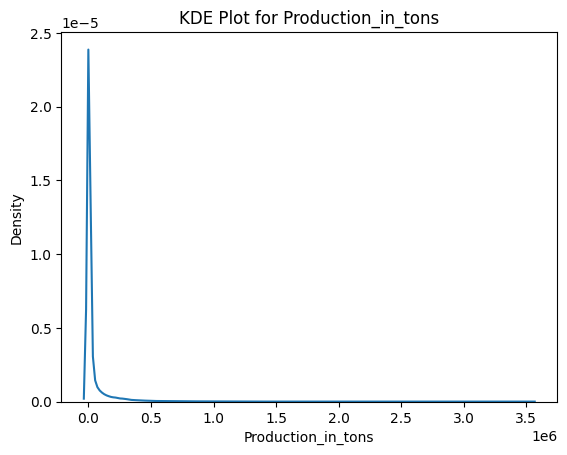

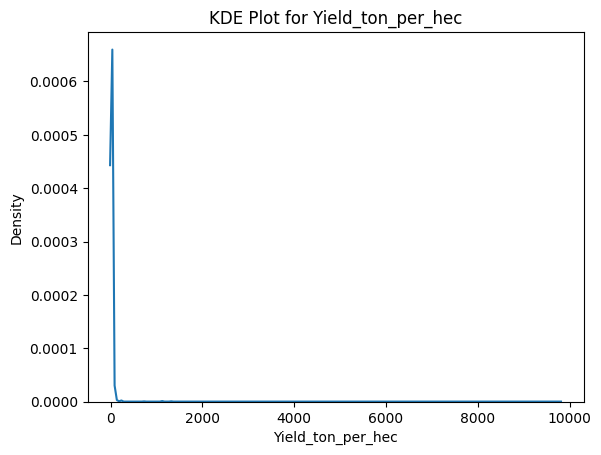

In [81]:
# Iterate over numerical columns and create KDE plots
for column in df.select_dtypes(exclude=['object']):
    sns.kdeplot(df[column])
    plt.title(f'KDE Plot for {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()


# *Inferences*
1. The nitrogen levels are more likely to be around 75 than at the extremes of 0 or 200 on the measured scale.
2. The graph indicates a central tendency around a moderate phosphorus concentration (around 50 units), with lower probabilities observed for both very low and very high levels.
3. According to data, Nitrogen contain in soil between 0 to 50kg/ha.

In [82]:
df1=df.select_dtypes(exclude=['object'])
df1.skew()

N                       0.912006
P                       0.120882
K                       1.754302
pH                      0.571347
rainfall                1.144965
temperature            -0.764792
Area_in_hectares        4.756932
Production_in_tons      7.225425
Yield_ton_per_hec     247.605260
dtype: float64

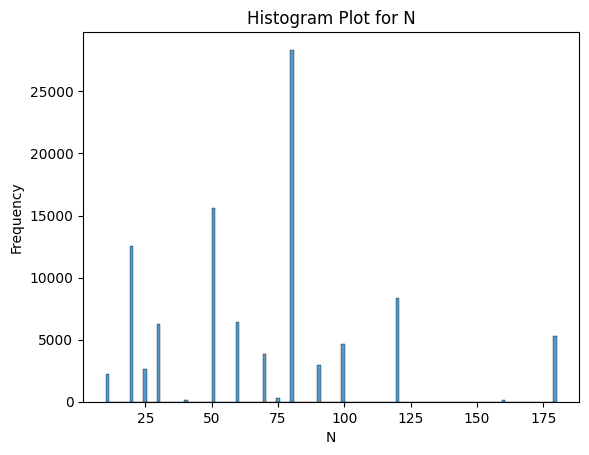

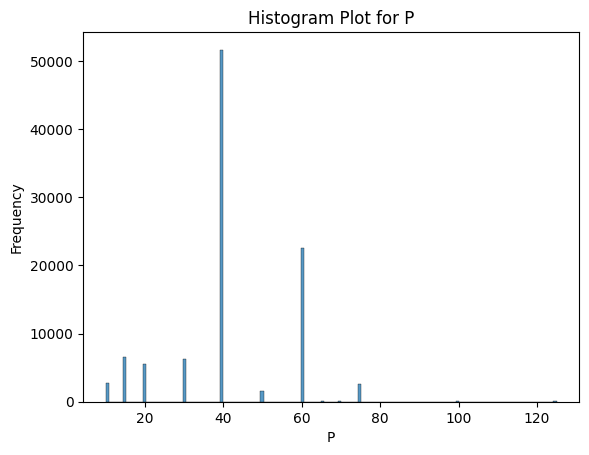

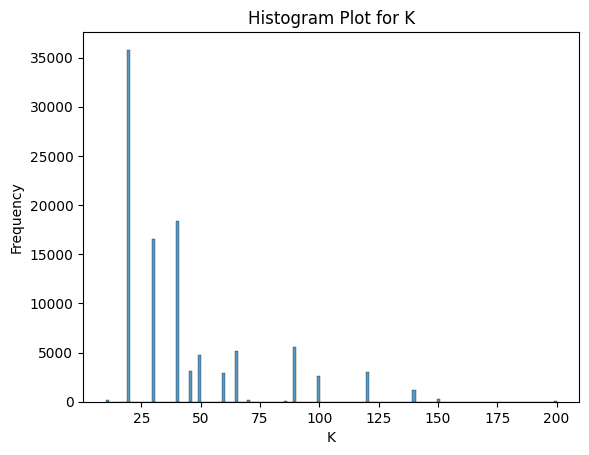

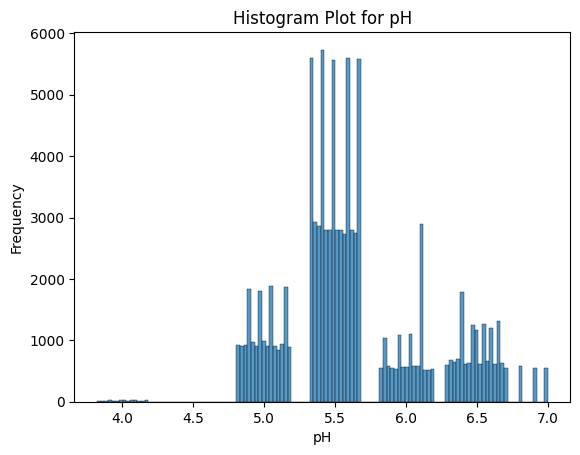

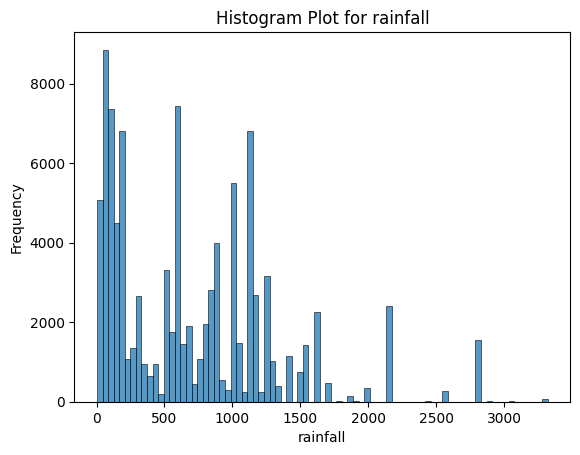

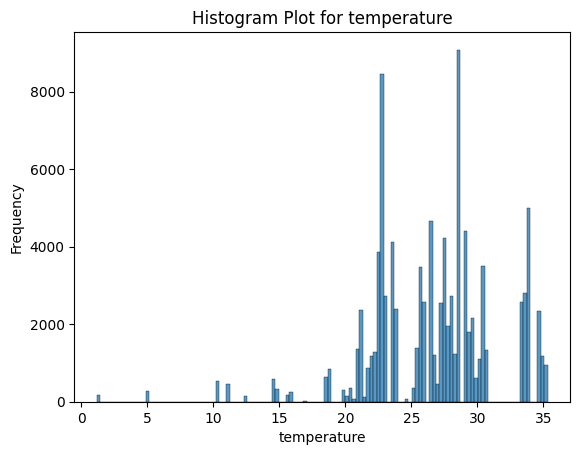

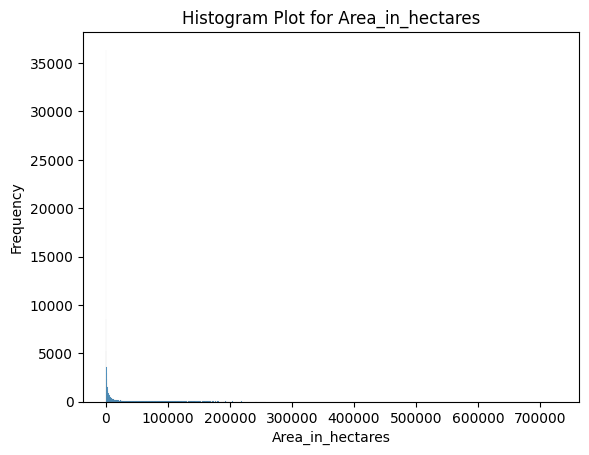

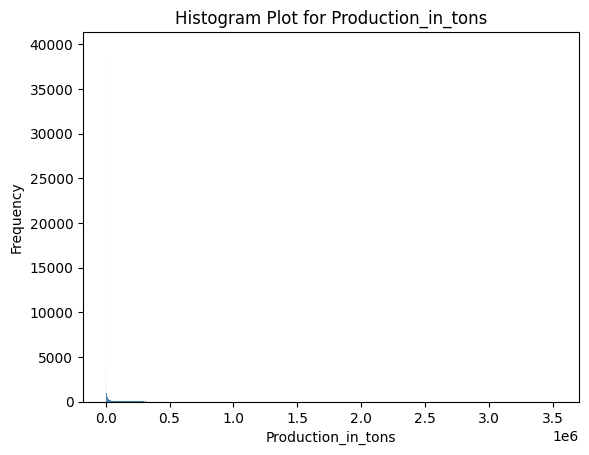

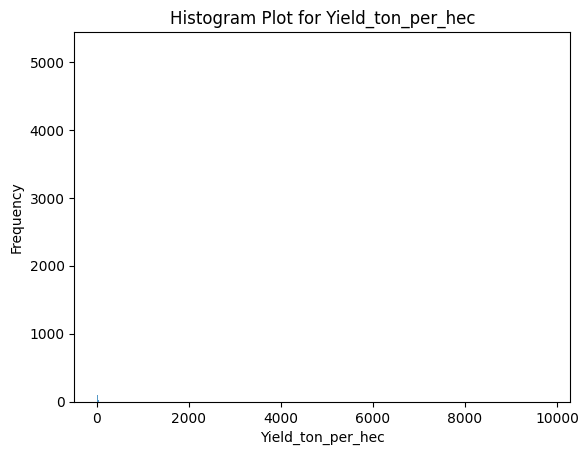

In [83]:
# Iterate over numerical columns and create KDE plots
for column in df.select_dtypes(exclude=['object']):
    sns.histplot(df[column])
    plt.title(f'Histogram Plot for {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

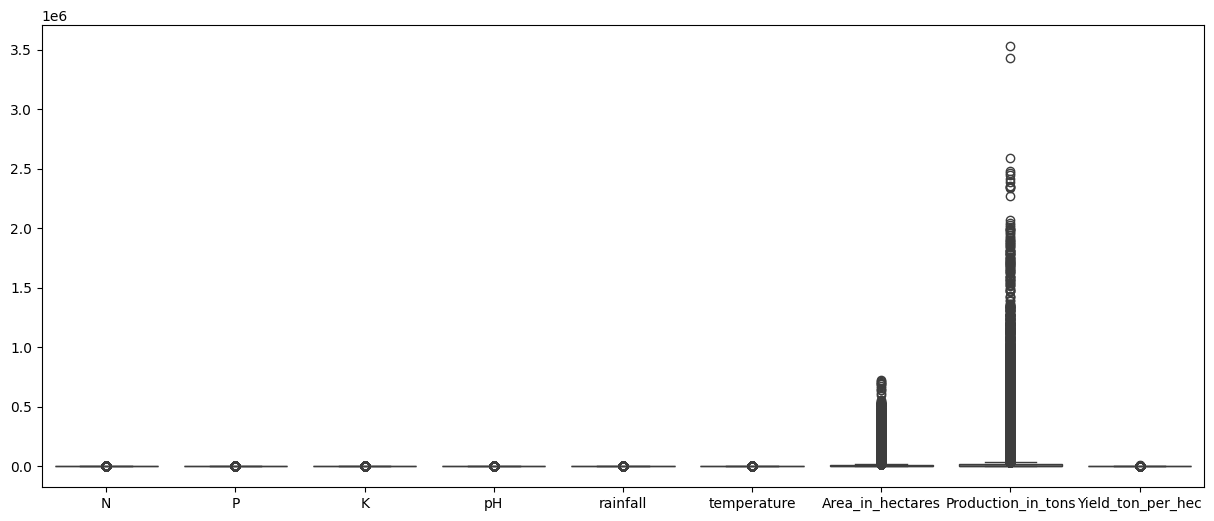

In [84]:
plt.figure(figsize=(15,6))
sns.boxplot(df)
plt.show()

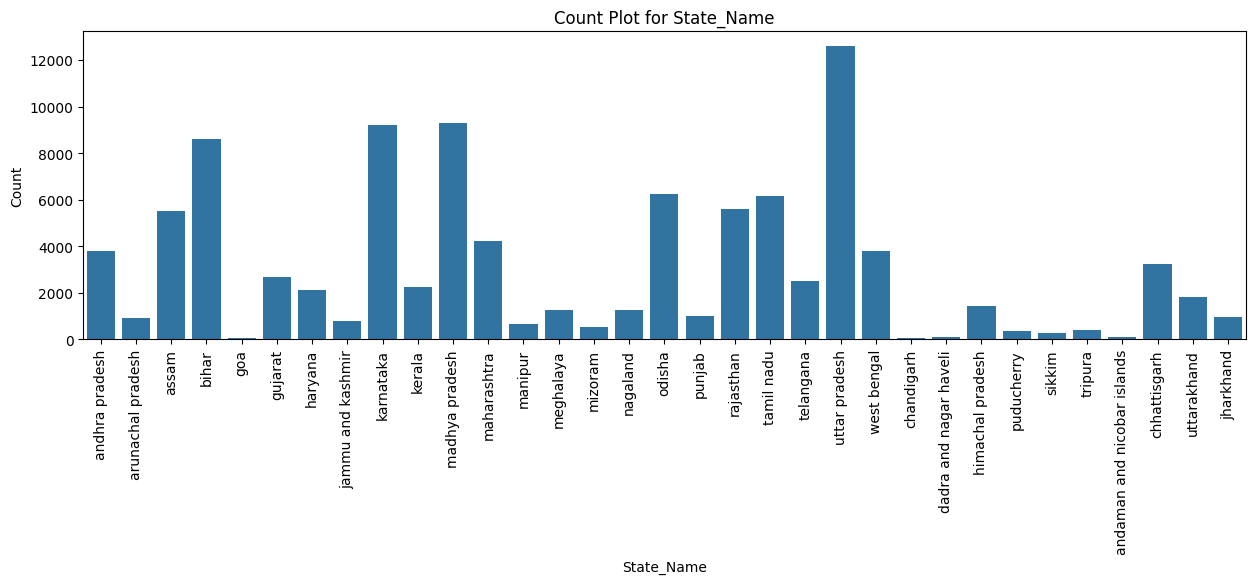

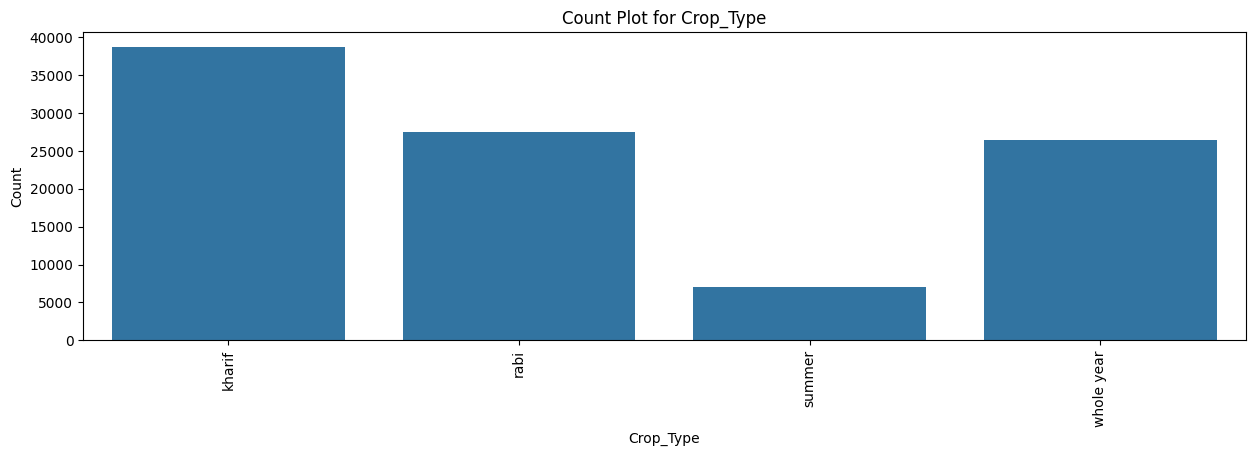

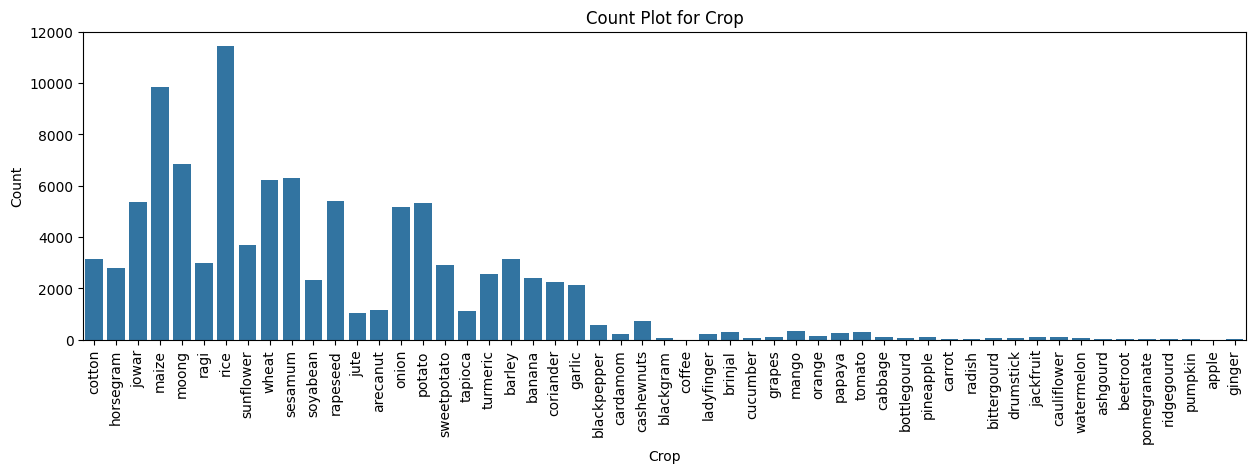

In [85]:
for column in df.select_dtypes(include=['object']):
    plt.figure(figsize=(15,4))
    sns.countplot(x=df[column])
    plt.title(f'Count Plot for {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()

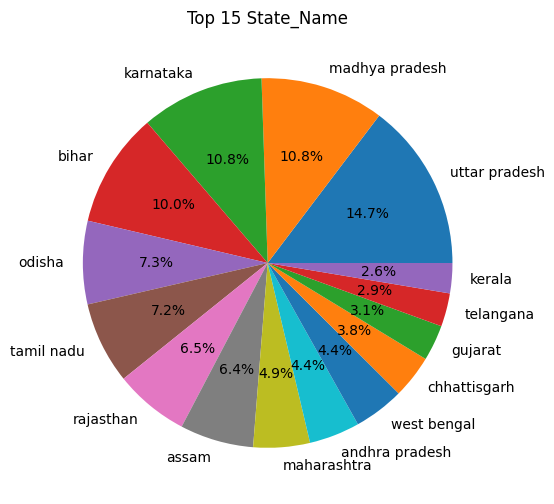

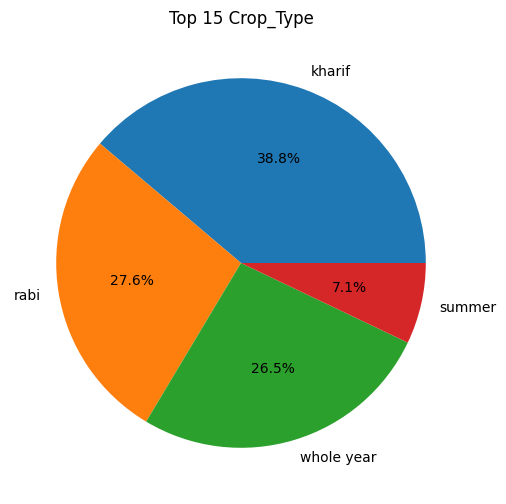

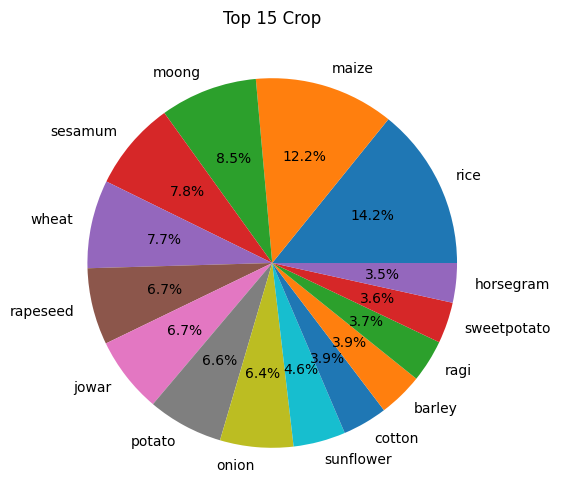

In [86]:
# Select categorical columns
df_categorical = df.select_dtypes(include=['object'])

# Loop through each categorical column
for column in df_categorical.columns:
    # Get the counts for each category
    category_counts = df_categorical[column].value_counts().head(15)  # Select top 5 categories
    
    # Create the pie chart
    plt.figure(figsize=(8, 6))  # Adjust the figure size if needed
    plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
    plt.title(f'Top 15 {column}')
    plt.show()




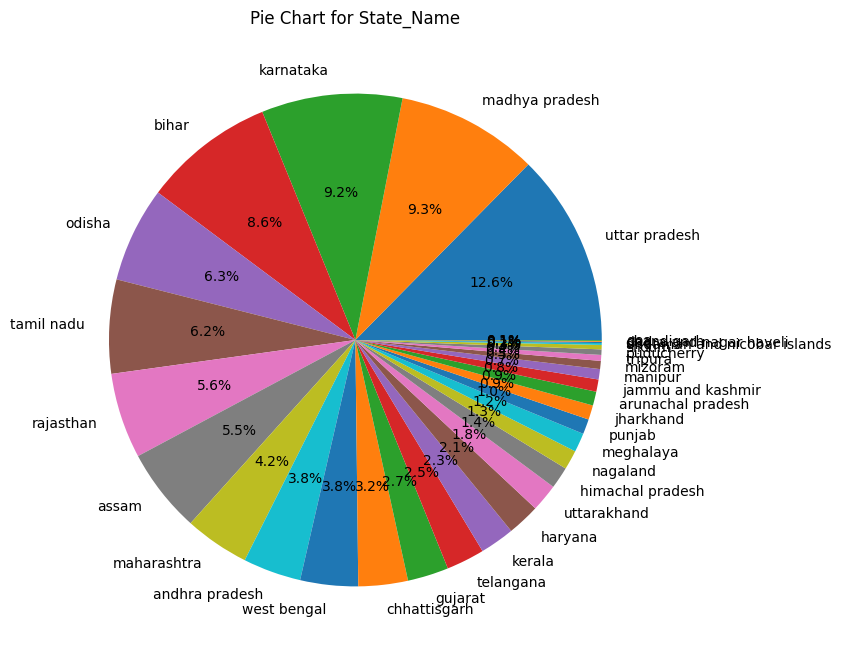

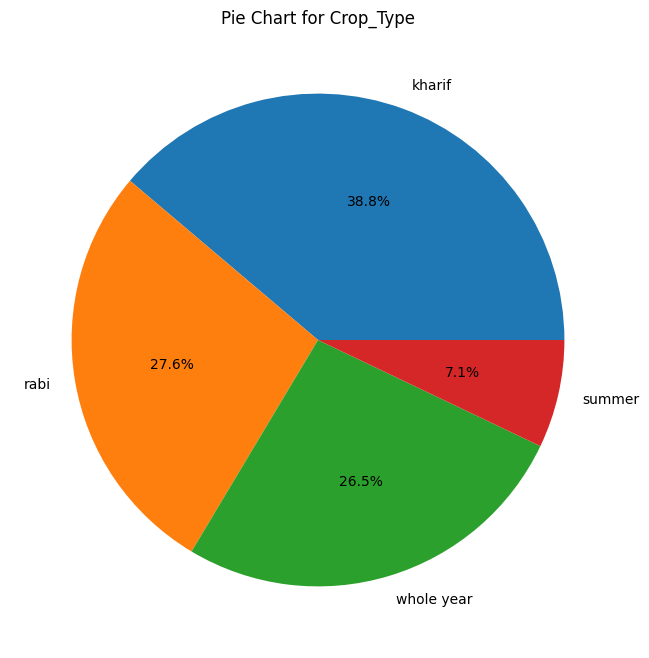

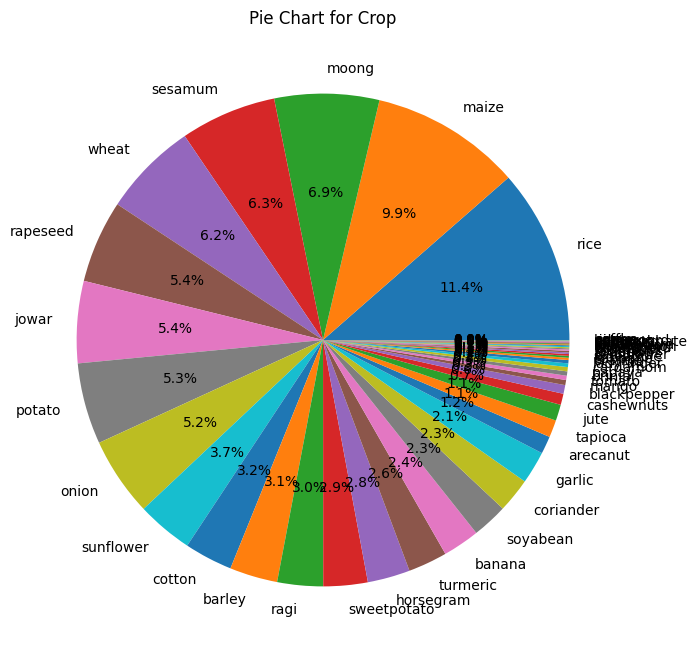

In [87]:
import matplotlib.pyplot as plt

# Select categorical columns
df_categorical = df.select_dtypes(include=['object'])

# Loop through each categorical column
for column in df_categorical.columns:
    # Get the counts for each category
    category_counts = df_categorical[column].value_counts()
    
    # Create the pie chart
    plt.figure(figsize=(8, 8))  # Adjust the figure size if needed
    plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
    plt.title(f'Pie Chart for {column}')
    plt.show()


<h2 style='font-family:rockwell; color:#06917e'> Bivariate Analysis</h2>

**For Numerical vs Numerical Columns** 
1. Scatter Plot 
2. Line plot
3. Jointplot
4. Regressionplot
5. heatmap



**For Numerical vs Categorical Columns** 
1.  Histograms with cat as hue(sns.displot())
2.  Violin plot as one of the axis as cat and other axis as num.
3.  Box plot as one of the axis as cat and other axis as num.
4.  Kde with cat as hue(sns.displot())
5.  Stripplot one of the axis as cat and other axis as num.
6.  Swarmplot one of the axis as cat and other axis as num.

**For Categorical vs Categorical**
1. tabulation 
     
			crosstab(tab_name['First_column_name'],table_name['Second_column_name])
			


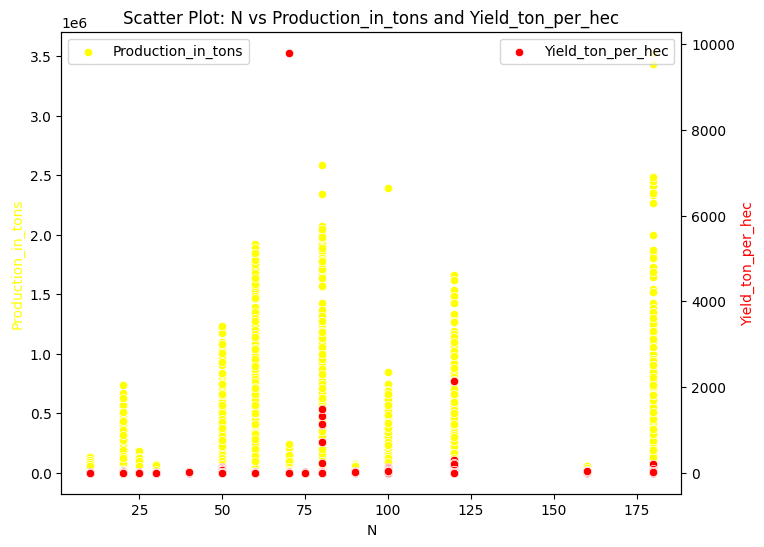

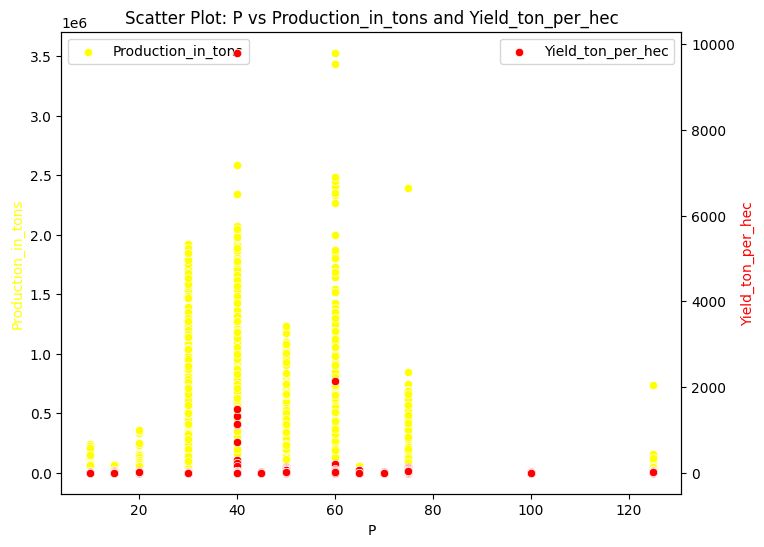

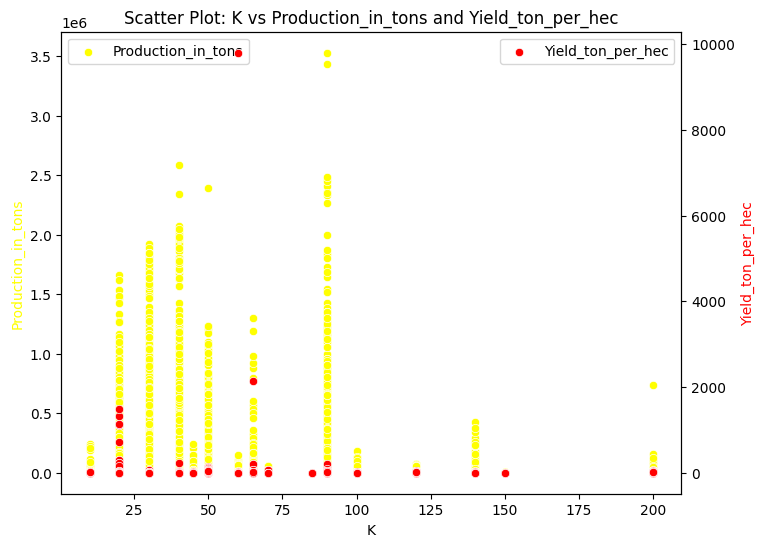

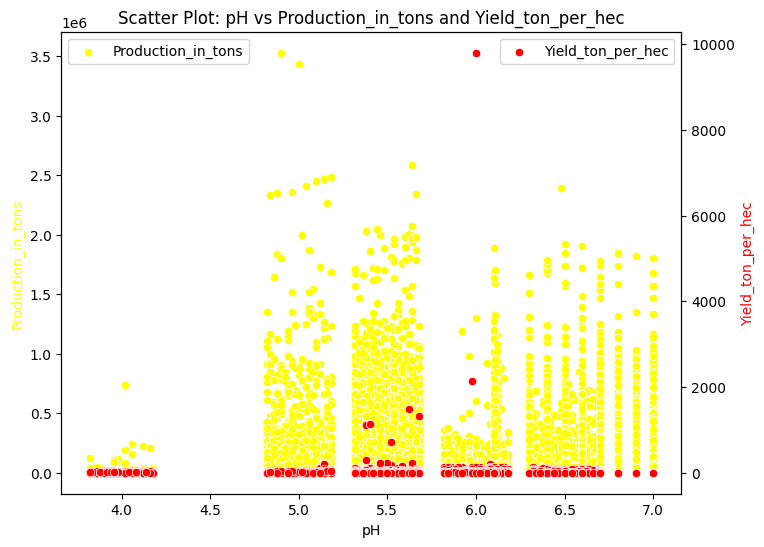

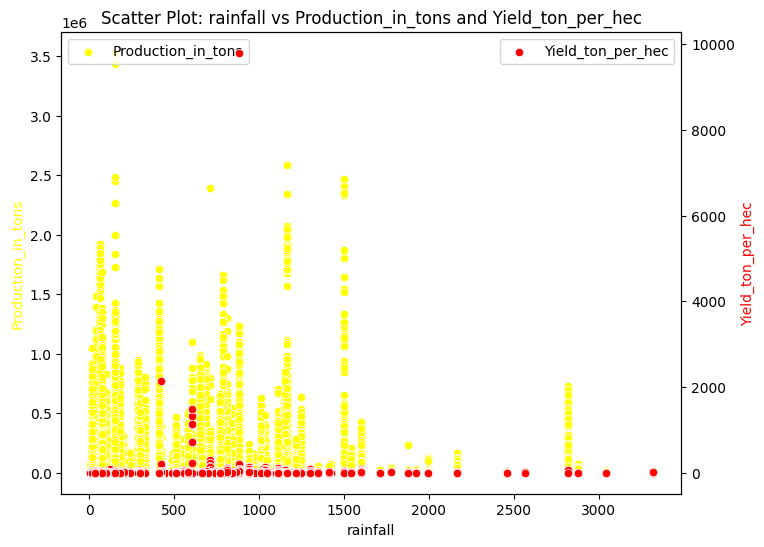

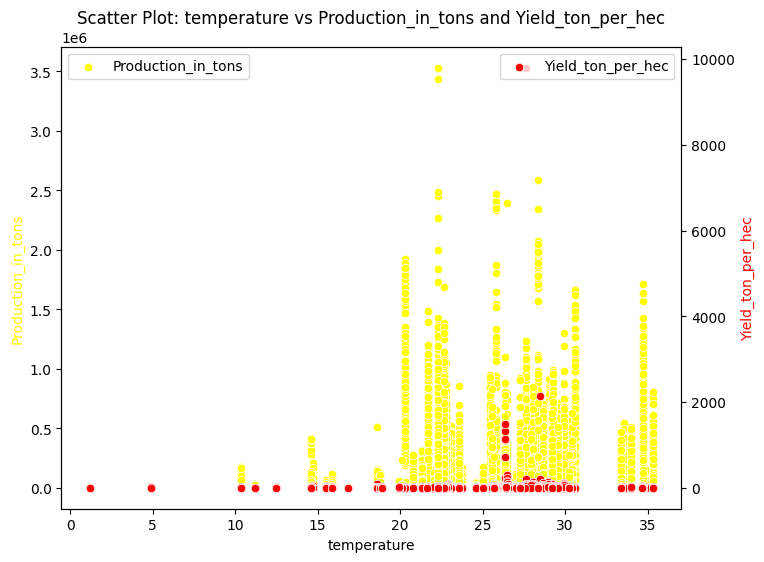

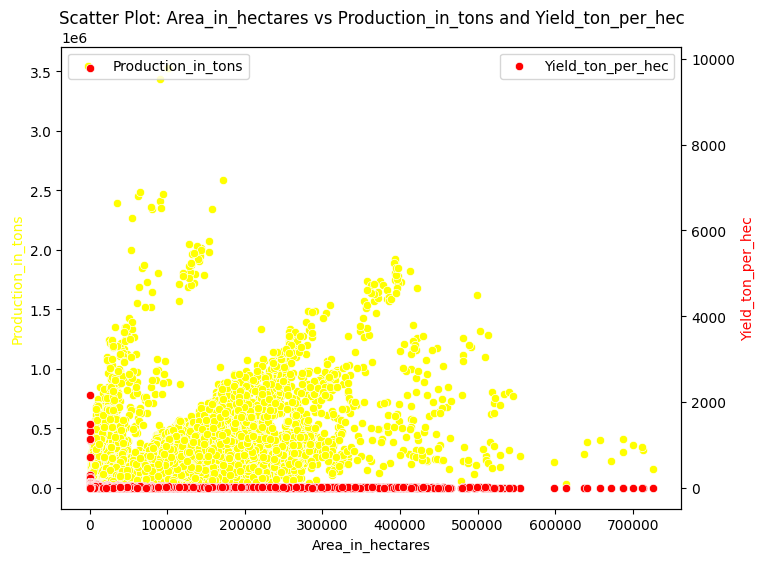

In [88]:
# List of numerical columns
numerical_columns = ['N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'Area_in_hectares']

# Iterate through each numerical column and create scatter plots
for column in numerical_columns:
    # Create subplots
    fig, ax1 = plt.subplots(figsize=(8, 6))

    # Plot 'Production_in_tons' on the first y-axis
    sns.scatterplot(x=df[column], y=df['Production_in_tons'], color='yellow', label='Production_in_tons', ax=ax1)
    ax1.set_ylabel('Production_in_tons', color='yellow')
    
    # Create a second y-axis for 'Yield_ton_per_hec'
    ax2 = ax1.twinx()
    sns.scatterplot(x=df[column], y=df['Yield_ton_per_hec'], color='red', label='Yield_ton_per_hec', ax=ax2)
    ax2.set_ylabel('Yield_ton_per_hec', color='red')
    
    # Set labels and title
    ax1.set_xlabel(column)
    plt.title(f'Scatter Plot: {column} vs Production_in_tons and Yield_ton_per_hec')
    
    # Show legend
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.show()


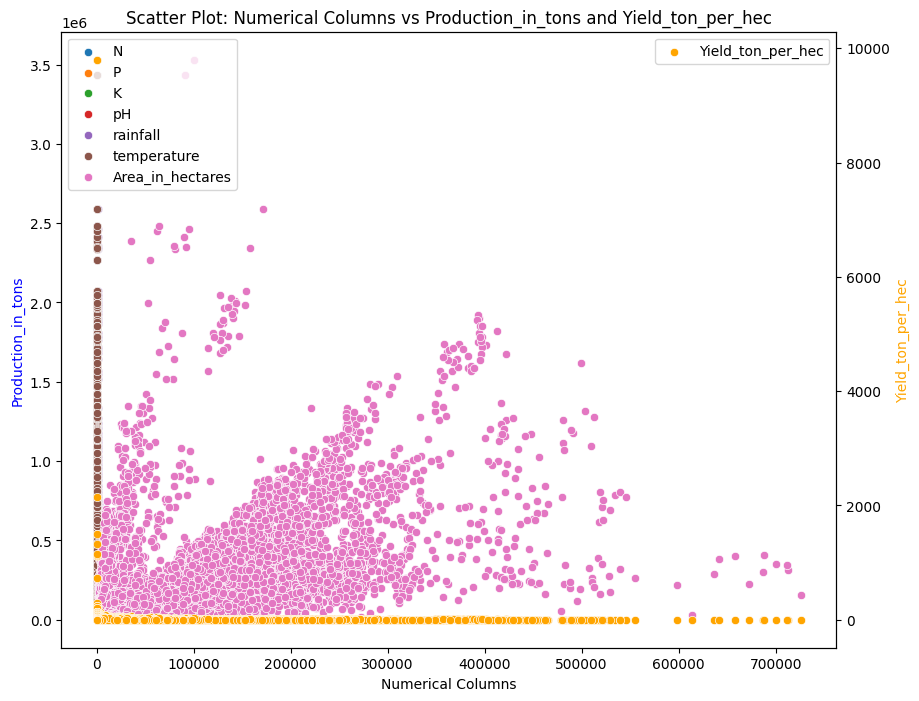

In [89]:
# List of numerical columns
numerical_columns = ['N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'Area_in_hectares']

# Create subplots
fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot each numerical column against 'Production_in_tons' on the first y-axis
for column in numerical_columns:
    sns.scatterplot(x=df[column], y=df['Production_in_tons'], label=column, ax=ax1)

# Create a second y-axis for 'Yield_ton_per_hec'
ax2 = ax1.twinx()
sns.scatterplot(x=df[column], y=df['Yield_ton_per_hec'], color='orange', label='Yield_ton_per_hec', ax=ax2)

# Set labels and title
ax1.set_xlabel('Numerical Columns')
ax1.set_ylabel('Production_in_tons', color='blue')
ax2.set_ylabel('Yield_ton_per_hec', color='orange')
plt.title('Scatter Plot: Numerical Columns vs Production_in_tons and Yield_ton_per_hec')

# Show legend
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()


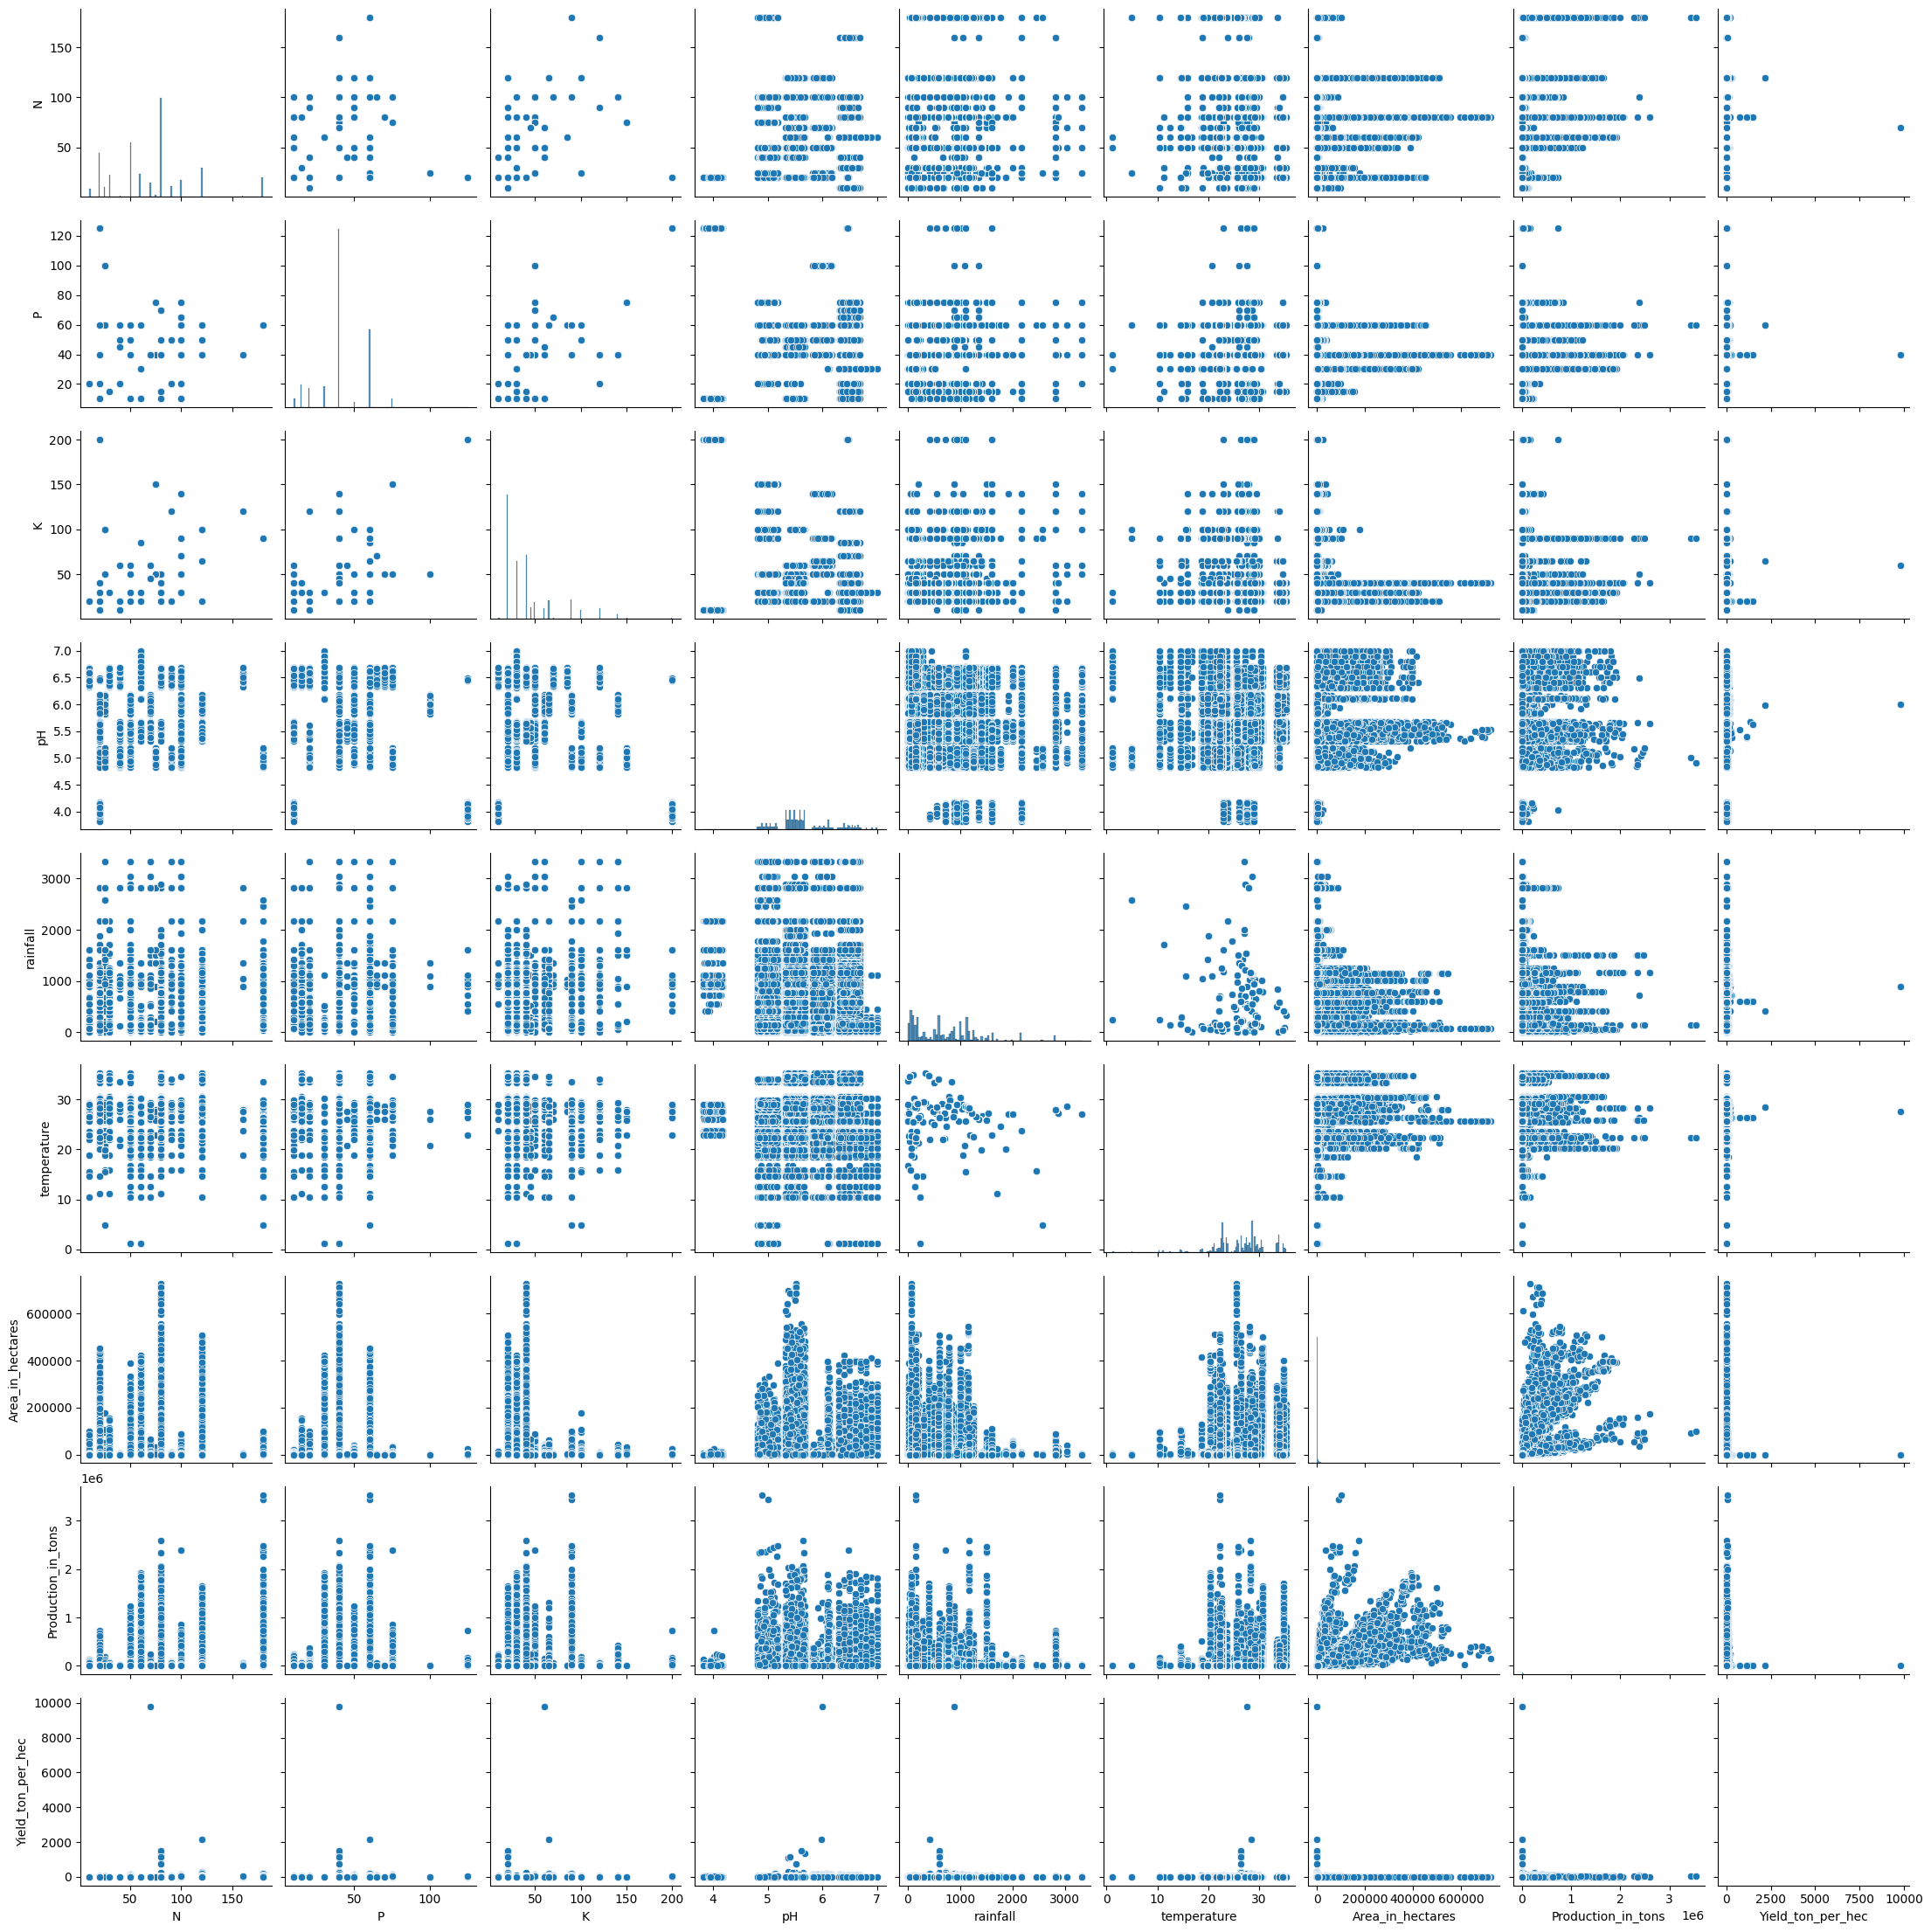

In [90]:
# Selecting a subset of columns for the pair plot
columns_for_pair_plot = ['N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'Area_in_hectares', 'Production_in_tons', 'Yield_ton_per_hec']

# Creating the pair plot
sns.pairplot(df[columns_for_pair_plot])
plt.show()


<h2 style='font-family:rockwell; color:#06917e'> Multivariate Analysis</h2>

**For Numerical vs Numerical Columns** 
1. Heatmap



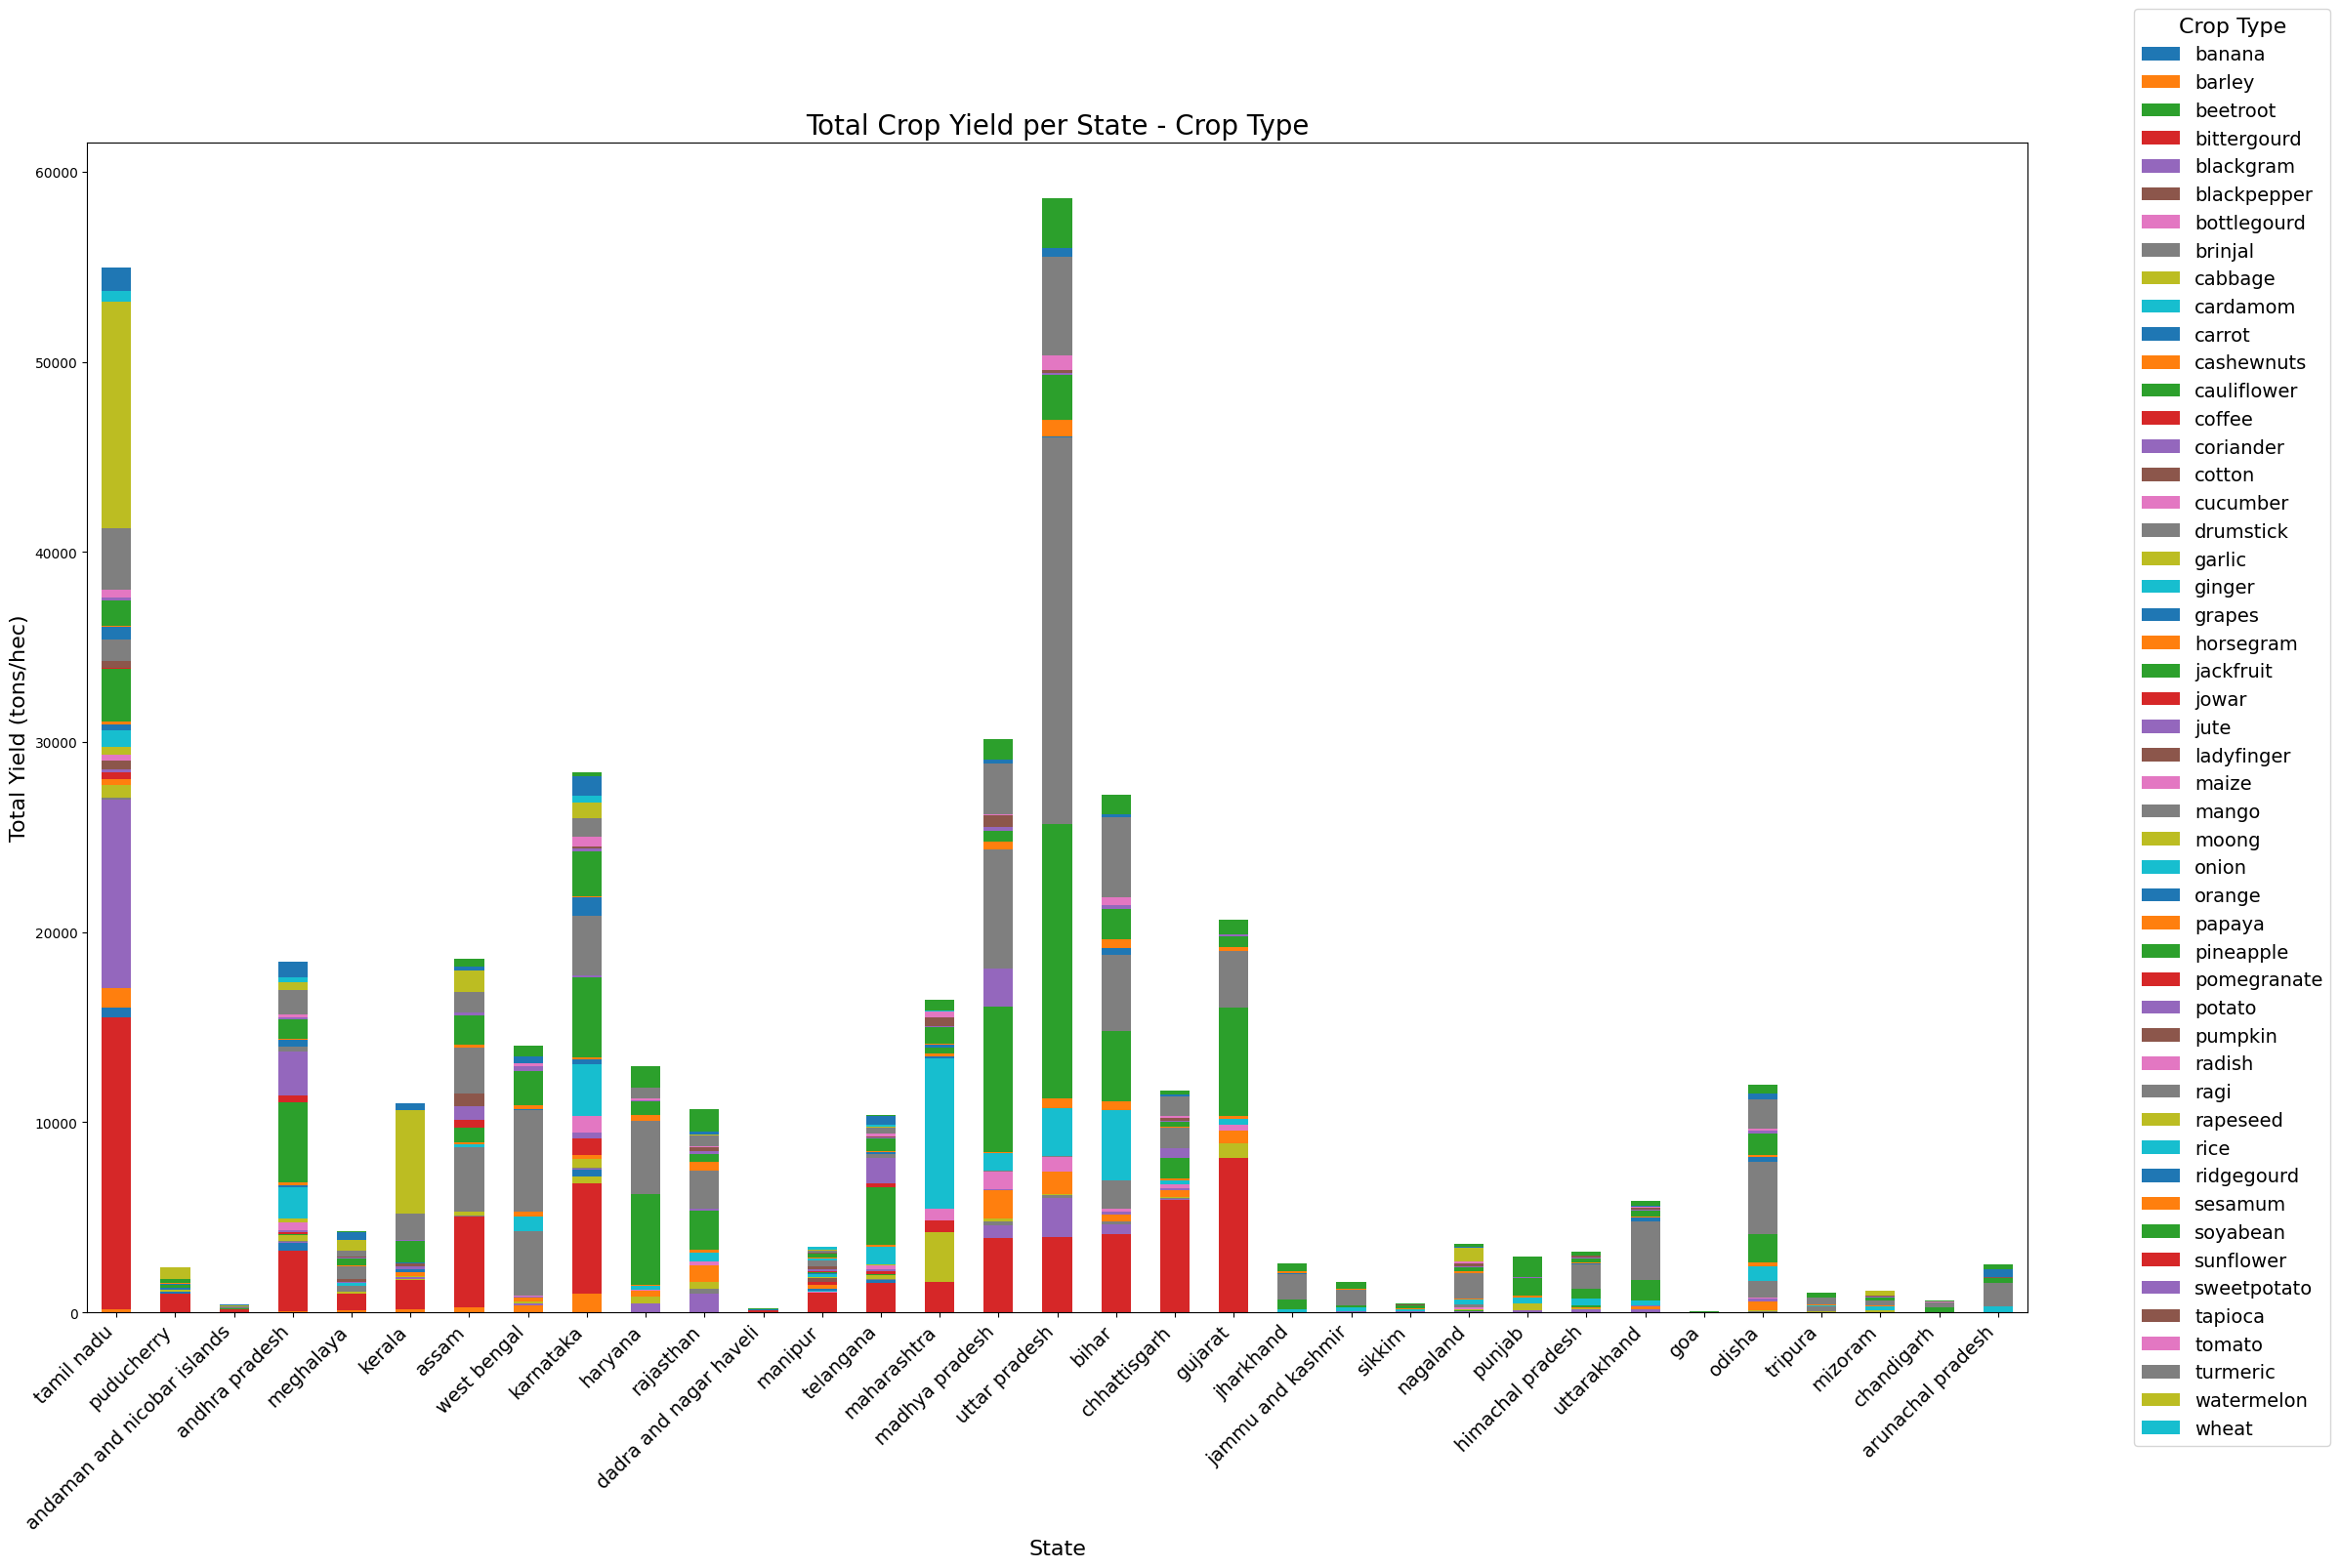

In [91]:

# Total Crop Yield per State - Crop Type
total_yield_per_area = df.groupby(by=['State_Name', 'Crop'])['Yield_ton_per_hec'].sum().unstack()
total_yield_per_area = total_yield_per_area.sort_values(by=total_yield_per_area.columns.tolist(), ascending=True)
g = total_yield_per_area.plot(kind='bar', stacked=True, figsize=(24, 16))  # Increase figure size here

# Setting plot title and labels with increased font size
plt.title('Total Crop Yield per State - Crop Type', fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.xlabel('State', fontsize=16)
plt.ylabel('Total Yield (tons/hec)', fontsize=16)

# Splitting legend into two sections
legend_top = total_yield_per_area.columns[:3]  # Top 3 crop types
legend_bottom = total_yield_per_area.columns[3:]  # Remaining crop types

# Plotting legend
plt.legend(title='Crop Type', fontsize=14, title_fontsize=16, ncol=1)  # Placeholder for bottom legend
plt.legend(legend_top, title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16, ncol=3)  # Top legend with 3 columns
plt.legend(legend_bottom, title='Crop Type', bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=14, title_fontsize=16, ncol=1)  # Bottom legend with 1 column

plt.tight_layout()
plt.show()


In [92]:
# ! pip install -U scikit-learn

In [93]:
# ! pip install statsmodels

In [94]:
df1=df.drop(columns='State_Name',axis=1)
df1.head()

,Crop_Type,Crop,N,P,K,pH,rainfall,temperature,Area_in_hectares,Production_in_tons,Yield_ton_per_hec
0,kharif,cotton,120,40,20,5.46,654.34,29.266667,7300.0,9400.0,1.287671
1,kharif,horsegram,20,60,20,6.18,654.34,29.266667,3300.0,1000.0,0.303030
2,kharif,jowar,80,40,40,5.42,654.34,29.266667,10100.0,10200.0,1.009901
3,kharif,maize,80,40,20,5.62,654.34,29.266667,2800.0,4900.0,1.750000
4,kharif,moong,20,40,20,5.68,654.34,29.266667,1300.0,500.0,0.384615


In [95]:
# ! pip install mlxtend

In [96]:
# ! pip install xgboost